# Recuperatorio 2025

Introducción: La municipalidad de Rosario quiere estimar un modelo del consumo energético dentro
de la ciudad y le encargó este trabajo a ustedes. Para esto, les proveyó los siguientes datasets:

Datos Medidos:
- id_ediﬁcio: Valor único de cada registro.
- tipo_ediﬁcio: Tipo de ediﬁcio.
- metros_cuadrados: Metros cuadrados de la propiedad.
- numero_ocupantes: Número de ocupantes de la propiedad.
- electrodomesticos: Cantidad de electrodomesticos/maquinaria en uso en la propiedad.
- temperatura_media: Temperatura media del día de la medición.
- dia_semana: Día de la semana cuando se realizó la medición.
- consumo_energia: Consumo energético de la propiedad en KWh.

Datos del barrio:
- id_ediﬁcio: Valor único de cada registro.
- barrio: Barrio donde se encuentra la propiedad.

# Parte I

In [120]:
# Importamos librerías

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
import numpy as np
from scipy.stats import norm, kurtosis
from statsmodels.stats.stattools import durbin_watson, jarque_bera
from scipy.stats import chi2

## Ejercicio 1

Importe ambos datasets y realice cualquier tarea de limpieza y adecuación de los mismos que
considere necesaria para su posterior análisis. Indicar la cantidad de registros que tiene cada uno de los
datasets.

In [121]:
# Cargamos los datasets

barrio = pd.read_csv('../../datasets/barrio_edificio.csv')
barrio.head()


,id_edificio,barrio
0,0,Norte
1,1,Norte
2,2,Norte
3,3,Centro
4,4,Oeste


In [122]:
barrio.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   id_edificio  1000 non-null   int64
 1   barrio       1000 non-null   str  
dtypes: int64(1), str(1)
memory usage: 15.8 KB


In [123]:
barrio["barrio"].unique()

# Observamos que el dataset barrio no tiene valores nulos o faltantes, y que el tipo de 
# dato de cada columna es correcto. También podemos observar que hay 1000 registros.

<StringArray>
['Norte', 'Centro', 'Oeste', 'Sur']
Length: 4, dtype: str

In [124]:
consumo = pd.read_csv('../../datasets/consumo_edificio.csv')
consumo.head()

,id_edificio,tipo_edificio,numero_ocupantes,electrodomesticos,temperatura_media,dia_semana,consumo_energia,metros_cuadrados
0,0,Residencial,76,10,29.84,habil,3264.235229,-800.581029
1,1,Comercial,66,45,16.72,fin_de_semana,6486.624735,4076.513979
2,2,Industrial,37,17,14.30,habil,4276.656672,2706.630060
3,3,Residencial,14,41,32.82,habil,3209.388291,805.112632
4,4,Comercial,26,18,11.92,habil,3266.871261,1175.467038


In [125]:
consumo.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id_edificio        1000 non-null   int64  
 1   tipo_edificio      1000 non-null   str    
 2   numero_ocupantes   1000 non-null   int64  
 3   electrodomesticos  1000 non-null   int64  
 4   temperatura_media  1000 non-null   float64
 5   dia_semana         1000 non-null   str    
 6   consumo_energia    1000 non-null   float64
 7   metros_cuadrados   1000 non-null   float64
dtypes: float64(3), int64(3), str(2)
memory usage: 62.6 KB


In [126]:
consumo["tipo_edificio"].unique()

<StringArray>
['Residencial', 'Comercial', 'Industrial']
Length: 3, dtype: str

In [127]:
consumo["dia_semana"].unique()

# Observamos que el dataset consumo no tiene valores nulos o faltantes, y que el tipo de 
# dato de cada columna es correcto. También podemos observar que hay 1000 registros en este dataset también.

<StringArray>
['habil', 'fin_de_semana']
Length: 2, dtype: str

In [128]:
# Vamos a unir ambos datasets para poder trabajar con ellos de manera conjunta. 
# Para esto, vamos a realizar un merge utilizando la columna "id_edificio" como clave.

data = pd.merge(consumo, barrio, on="id_edificio")
data.head()

,id_edificio,tipo_edificio,numero_ocupantes,electrodomesticos,temperatura_media,dia_semana,consumo_energia,metros_cuadrados,barrio
0,0,Residencial,76,10,29.84,habil,3264.235229,-800.581029,Norte
1,1,Comercial,66,45,16.72,fin_de_semana,6486.624735,4076.513979,Norte
2,2,Industrial,37,17,14.30,habil,4276.656672,2706.630060,Norte
3,3,Residencial,14,41,32.82,habil,3209.388291,805.112632,Centro
4,4,Comercial,26,18,11.92,habil,3266.871261,1175.467038,Oeste


## Ejercicio 2

Muestre la distribución del consumo de energía por tipo de ediﬁcio. Explique el resultado
obtenido a su clienta que no tiene una formación técnica.

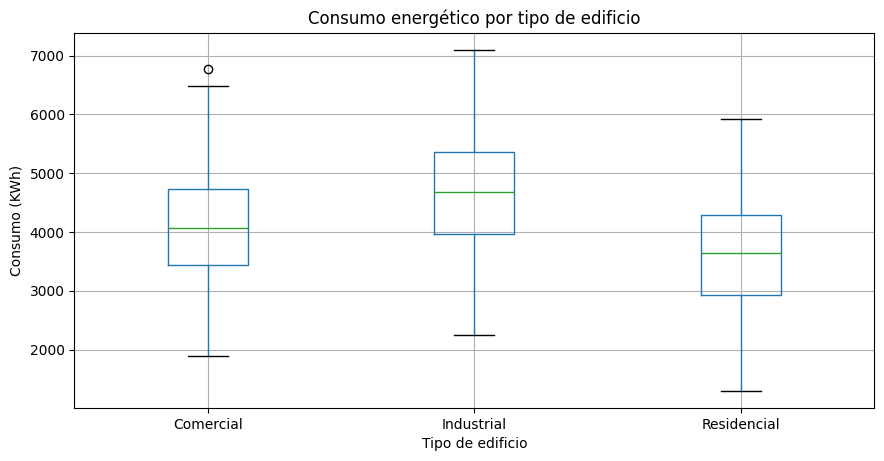

In [129]:
# Vamos a realizar un histograma

data.boxplot(column="consumo_energia", by="tipo_edificio", figsize=(10,5))

plt.title("Consumo energético por tipo de edificio")
plt.suptitle("")
plt.ylabel("Consumo (KWh)")
plt.xlabel("Tipo de edificio")

plt.show()

Querida clienta, podemos observar que hay diferencias entre los consumos de los distintos tipos de edificios. En los edificios de tipo industrial la media de consumo es mayor, seguida por los edificios comerciales y por último los esficios residenciales. En el caso de los edificios la media es cercana a los 4800 kwh, los edificios comerciales tienen una media cercana a los 4000 kwh y los edificios residenciales cercana a los 3700 kwh.

## Ejercicio 3

Su clienta está preocupada porque alguien le dijo que los datos de temperatura están
sesgados. Podría veriﬁcar esta información y escribir un mensaje para enviarle a su clienta?

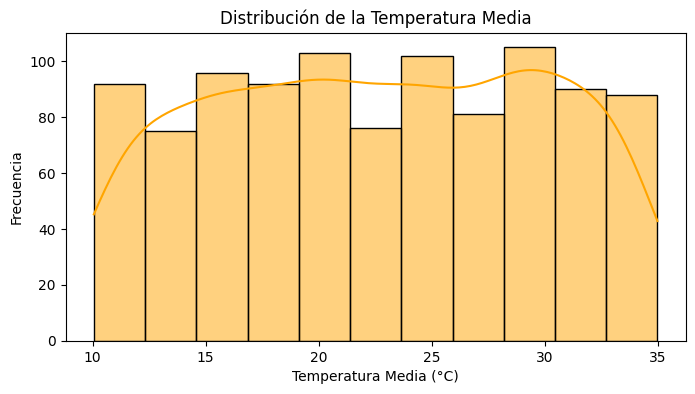

In [130]:
# Analizamos el sesgo mediante un histograma, gráfico de densidad y cálculo matemático

plt.figure(figsize=(8, 4))
sns.histplot(data['temperatura_media'], kde=True, color='orange')
plt.title('Distribución de la Temperatura Media')
plt.xlabel('Temperatura Media (°C)')
plt.ylabel('Frecuencia')
plt.show()

Estimada clienta, 

Nos pusimos a investigar la inquietud que nos transmitiste sobre el posible sesgo en los datos de temperatura. Queremos llevarte tranquilidad: tras realizar las pruebas estadísticas y analizar la distribución de los registros, no encontramos un sesgo alarmante.

Los datos se distribuyen de forma bastante pareja y natural (la mayoría de los días se concentran en temperaturas medias templadas, disminuyendo equitativamente hacia los días de frío o calor extremo). Podés confiar en que esta variable es sólida para continuar con el modelo de la Municipalidad. Quedamos a disposición si necesitás que te mostremos el gráfico de respaldo. 

¡Saludos!

# Ejercicio 4

Realice un gráﬁco que nos muestre como varía el consumo de energía con respecto al número
de ocupantes que tiene la propiedad. Describa esta relación para su clienta.

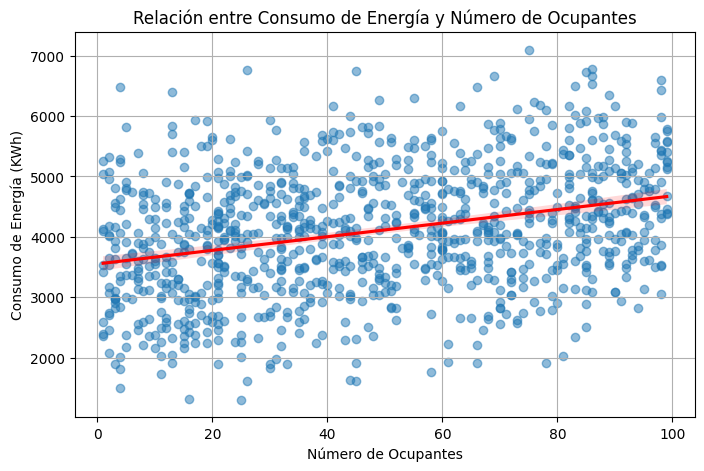

In [131]:
# Usamos un gráfico de dispersión (Scatter plot) con línea de tendencia

plt.figure(figsize=(8, 5))

sns.regplot(data=data, x='numero_ocupantes', y='consumo_energia', 
            scatter_kws={'alpha':0.5}, line_kws={'color':'red'})

plt.title('Relación entre Consumo de Energía y Número de Ocupantes')
plt.xlabel('Número de Ocupantes')
plt.ylabel('Consumo de Energía (KWh)')
plt.grid(True)

plt.show()

In [132]:
# Calculamos la correlación para tener el dato técnico de respaldo

correlacion = data['numero_ocupantes'].corr(data['consumo_energia'])
print(f"Coeficiente de correlación de Pearson: {correlacion:.2f}")

Coeficiente de correlación de Pearson: 0.32


Estimada clienta,

Analizamos el impacto que tiene la cantidad de personas que habitan o concurren a una propiedad sobre el medidor de luz.

Encontramos una relación directa y positiva: a medida que aumenta el número de ocupantes en una propiedad, el consumo de energía también tiende a subir de forma sostenida (lo cual se visualiza en la línea de tendencia ascendente del gráfico). Esto valida la hipótesis de que el factor humano y residencial es un motor clave en la demanda energética de la ciudad, permitiéndonos predecir mejor el gasto en base al crecimiento demográfico de los barrios.

# Parte II

El objetivo principal de esta segunda parte es analizar si es factible ajustar un modelo de regresión lineal
que permita predecir el consumo energético de un ediﬁcio de la ciudad.

## Ejercicio 1

Ajuste un modelo para predecir el consumo de energía utilizando la totalidad de las variables
presentadas. Se solicita que las variables explicativas, exceptos las dummies, estén estandarizadas de la
siguiente forma:

$$Zi = \frac{X_i - \overline{X}}{s}$$

Donde:
- $Z_i$ es el valor estandarizado,
- $X_i$ es la valor de la variable original,
- $\overline{X}$ es la media de la muestra de $X$,
- $s$ es la desviación estándar de la muestra de $X$.

In [137]:
# Vamos a generar un nuevo data set con las variables estandarizadas

var_num = ['metros_cuadrados', 'numero_ocupantes', 'electrodomesticos', 'temperatura_media']
data_est = data.copy()
for col in var_num:
    data_est[col] = (data_est[col] - data_est[col].mean()) / data_est[col].std()

data_est.head()

,id_edificio,tipo_edificio,numero_ocupantes,electrodomesticos,temperatura_media,dia_semana,consumo_energia,metros_cuadrados,barrio
0,0,Residencial,0.950658,-1.106403,1.012419,habil,3264.235229,-2.041998,Norte
1,1,Comercial,0.606566,1.374957,-0.825131,fin_de_semana,6486.624735,1.103224,Norte
2,2,Industrial,-0.391302,-0.610131,-1.164070,habil,4276.656672,0.219791,Norte
3,3,Residencial,-1.182714,1.091373,1.429789,habil,3209.388291,-1.006491,Centro
4,4,Comercial,-0.769803,-0.539235,-1.497406,habil,3266.871261,-0.767651,Oeste


In [135]:
modelo = smf.ols(formula = "consumo_energia ~ metros_cuadrados + numero_ocupantes + electrodomesticos + temperatura_media + tipo_edificio + dia_semana + barrio", data=data_est).fit()
print(modelo.summary())

                            OLS Regression Results                            
Dep. Variable:        consumo_energia   R-squared:                       0.744
Model:                            OLS   Adj. R-squared:                  0.741
Method:                 Least Squares   F-statistic:                     287.0
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          3.17e-284
Time:                        22:14:47   Log-Likelihood:                -7679.8
No. Observations:                1000   AIC:                         1.538e+04
Df Residuals:                     989   BIC:                         1.544e+04
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

# Ejercicio 2

En base al modelo anterior, quitar todas las variables que no sean estadísticamente signiﬁcativas. Consideramos que estadísticamente signiﬁcativo implica que la probabilidad que el coeﬁciente estimado sea cero es menor al 5%.

Podemos observar que las variables que no son estadísticamente signiﬁcativas `temperatura_media` y `dia_semana`. Las eliminamos del modelo.

In [138]:
modelo2 = smf.ols(formula = "consumo_energia ~ metros_cuadrados + numero_ocupantes + electrodomesticos + tipo_edificio + barrio", data=data_est).fit()
print(modelo2.summary())

                            OLS Regression Results                            
Dep. Variable:        consumo_energia   R-squared:                       0.742
Model:                            OLS   Adj. R-squared:                  0.740
Method:                 Least Squares   F-statistic:                     356.3
Date:                Sun, 07 Jun 2026   Prob (F-statistic):          2.41e-285
Time:                        22:18:02   Log-Likelihood:                -7683.2
No. Observations:                1000   AIC:                         1.538e+04
Df Residuals:                     991   BIC:                         1.543e+04
Df Model:                           8                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
Intercept       

## Ejercicio 3

La propiedad de la empresa "AlfajoresRicos" tiene un consumo sospechosamente bajo de 3000
KWh. Su clienta le pide que use el modelo para estimar el consumo de la propiedad y si el consumo que
usted encuentra es 20% mayor 3000 KWh, deberá informarle a su clienta para que inicie una investigación a
"AlfajoresRicos".

Características de la propiedad y día de medición:

| Variable | Valor original | Valor estandarizado |
| :--- | :---: | :---: |
| **tipo_edificio** | Industrial | *NA* |
| **numero_ocupantes** | 26 | -0.766 |
| **electrodomesticos** | 19 | -0.464 |
| **temperatura_media** | 20 | -0.374 |
| **dia_semana** | habil | *NA* |
| **metros_cuadrados** | 5000 | 1.736 |
| **barrio** | Centro | *NA* |


In [ ]:
# Datos del reporte OLS (Coeficientes del modelo nuevo)

intercepto = 4510.6071
b_industrial = 472.6365
b_metros = 613.4414
b_ocupantes = 277.9525
b_electro = 290.0502
# Barrio Centro es la categoría base (coeficiente = 0)

# Valores estandarizados de la propiedad

metros_est = 1.736
ocupantes_est = -0.766
electro_est = -0.464

# Cálculo de la predicción matemática

consumo_estimado = (
    intercepto 
    + b_industrial 
    + (b_metros * metros_est) 
    + (b_ocupantes * ocupantes_est) 
    + (b_electro * electro_est)
)

print(f"Consumo estimado por el modelo: {consumo_estimado:.2f} KWh")

# Verificación del límite de sospecha (+20% sobre los 3000 KWh declarados)

consumo_reportado = 3000
limite_sospecha = consumo_reportado * 1.20 # 3600 KWh

if consumo_estimado > limite_sospecha:
    print(f"ALERTA: El consumo estimado ({consumo_estimado:.2f} KWh) supera el límite de {limite_sospecha} KWh. SE DEBE INVESTIGAR.")
else:
    print("El consumo está dentro de los parámetros normales.")

Consumo estimado por el modelo: 5700.68 KWh
ALERTA: El consumo estimado (5700.68 KWh) supera el límite de 3600.0 KWh. SE DEBE INVESTIGAR.


## Ejercicio 4

Cual es la diferencia estimada en el consumo energético entre dos locales comerciales idénticos pero uno está en el Centro y el otro en zona Sur.

En nuestro modelo de regresión lineal, las categorías de las variables cualitativas (como los barrios) se analizan en comparación con una categoría de referencia o "base". Al observar el reporte, notamos que el barrio **Centro** no aparece con una fila propia; esto significa que el sistema lo eligió automáticamente como la base del modelo, asignándole un valor implícito de $0$.

Por otra parte, la variable correspondiente al barrio **Sur** (`barrio[T.Sur]`) posee un coeficiente estimado de **$-702.31$**.

Esto se interpreta de la siguiente manera: manteniendo todas las demás variables constantes y bajo condiciones idénticas (mismos metros cuadrados, misma cantidad de ocupantes y de electrodomésticos), un local comercial ubicado en la **Zona Sur** consumirá en promedio **702.31 KWh menos** que uno ubicado en el **Centro**. 

Por lo tanto, la diferencia estimada en el consumo energético entre ambos locales es exactamente de **702.31 KWh**.